In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral525.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral515.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral513.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral382.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral487.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral563.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral370.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral366.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral374.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral148.jpeg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral149.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral604.png
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral73.png
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral205.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral507.jpg
/kaggle/input/vsa-data3/Main/ValMain/val

In [2]:
!pip -q install easyocr opencv-python-headless


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.5 MB/s eta 0:00:00:00:0100:01


In [3]:
import os
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import CLIPProcessor, CLIPModel

import easyocr

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


2025-08-22 11:47:01.911713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755863222.124539      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755863222.184679      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
# ============ Config ============
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

DATA_ROOT = "/kaggle/input/vsa-data3/Main"
TRAIN_DIR = os.path.join(DATA_ROOT, "TrainMain", "validated")
VAL_DIR   = os.path.join(DATA_ROOT, "ValMain", "val")
TEST_DIR  = os.path.join(DATA_ROOT, "TestMain", "test")

CLASS_NAMES = ["negative", "neutral", "positive"]
BATCH_SIZE = 16
EPOCHS = 10
USE_OCR = True  # toggle OCR on/off
# =================================

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Lazy global OCR reader (handles CPU/GPU automatically)
_EASY_OCR_READER = None
def get_ocr_reader():
    global _EASY_OCR_READER
    if _EASY_OCR_READER is None:
        _EASY_OCR_READER = easyocr.Reader(['en'], gpu=(DEVICE=="cuda"))
    return _EASY_OCR_READER


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [5]:
class VSADataset(Dataset):
    def __init__(self, root_dir, processor, class_names, use_ocr=False):
        self.root_dir = root_dir
        self.processor = processor
        self.samples = []
        self.class_to_idx = {name.lower(): i for i, name in enumerate(class_names)}
        self.use_ocr = use_ocr

        for cname in class_names:
            folder_name = next((d for d in os.listdir(root_dir) if d.lower() == cname.lower()), None)
            if folder_name is None:
                raise ValueError(f"Class folder {cname} not found in {root_dir}")
            cdir = os.path.join(root_dir, folder_name)
            for f in os.listdir(cdir):
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                    self.samples.append((os.path.join(cdir, f), self.class_to_idx[cname.lower()]))

    def __len__(self):
        return len(self.samples)

    def _ocr_easy(self, img: Image.Image) -> str:
        try:
            reader = get_ocr_reader()
            # EasyOCR expects numpy array; detail=0 returns strings only
            txts = reader.readtext(np.array(img), detail=0)
            text = " ".join(t.strip() for t in txts if isinstance(t, str)).strip()
            return text if text else "no text"
        except Exception:
            return "no text"

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        ocr_text = self._ocr_easy(img) if self.use_ocr else "dummy"

        inputs = self.processor(
            images=img,
            text=[ocr_text],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=77
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
            "ocr_text": ocr_text
        }


In [6]:
train_dataset = VSADataset(TRAIN_DIR, processor, CLASS_NAMES, use_ocr=USE_OCR)
val_dataset   = VSADataset(VAL_DIR,   processor, CLASS_NAMES, use_ocr=USE_OCR)
test_dataset  = VSADataset(TEST_DIR,  processor, CLASS_NAMES, use_ocr=USE_OCR)

# EasyOCR + multiprocessing can be finicky; use num_workers=0 for stability
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=(DEVICE=="cuda"))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))


In [7]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
for p in clip_model.parameters():
    p.requires_grad = False

vision_dim = clip_model.visual_projection.out_features
text_dim   = clip_model.text_projection.out_features
fused_dim  = vision_dim + text_dim  # we keep same concat-sized vector after gating


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [8]:
class AttentionGate(nn.Module):
    """
    Learn a scalar gate alpha in [0,1] to balance v (vision) vs t (text).
    fused = [alpha * v, (1-alpha) * t]  --> same size as simple concat but weighted.
    """
    def __init__(self, v_dim, t_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(v_dim + t_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )

    def forward(self, v, t):
        vt = torch.cat([v, t], dim=-1)
        alpha = self.net(vt)           # (B,1)
        v_w = alpha * v
        t_w = (1.0 - alpha) * t
        return torch.cat([v_w, t_w], dim=-1), alpha.squeeze(-1)  # fused, alpha


In [9]:
class ClassifierHead(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.mlp(x)


In [10]:
fusion = AttentionGate(vision_dim, text_dim).to(DEVICE)
classifier = ClassifierHead(fused_dim, len(CLASS_NAMES)).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    list(fusion.parameters()) + list(classifier.parameters()),
    lr=1e-4, weight_decay=1e-4
)


In [11]:
def extract_features(batch):
    images = batch["pixel_values"].to(DEVICE)
    input_ids = batch["input_ids"].to(DEVICE)
    attention_mask = batch["attention_mask"].to(DEVICE)

    with torch.no_grad():
        v = clip_model.get_image_features(images)
        t = clip_model.get_text_features(input_ids=input_ids, attention_mask=attention_mask)
    # Normalize features (often helps with CLIP)
    v = v / (v.norm(dim=-1, keepdim=True) + 1e-6)
    t = t / (t.norm(dim=-1, keepdim=True) + 1e-6)
    return v, t


In [12]:
def train_one_epoch(loader):
    clip_model.eval()
    fusion.train()
    classifier.train()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    for batch in loader:
        labels = batch["labels"].to(DEVICE)
        v, t = extract_features(batch)

        optimizer.zero_grad()
        fused, _ = fusion(v, t)
        logits = classifier(fused)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


In [13]:
@torch.no_grad()
def evaluate(loader):
    clip_model.eval()
    fusion.eval()
    classifier.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    for batch in loader:
        labels = batch["labels"].to(DEVICE)
        v, t = extract_features(batch)
        fused, _ = fusion(v, t)
        logits = classifier(fused)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


In [14]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(train_loader)
    va_loss, va_acc = evaluate(val_loader)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accuracies.append(tr_acc)
    val_accuracies.append(va_acc)

    print(f"Epoch {epoch:02d} | Train Loss {tr_loss:.4f} | Train Acc {tr_acc:.4f} | "
          f"Val Loss {va_loss:.4f} | Val Acc {va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({
            "fusion": fusion.state_dict(),
            "classifier": classifier.state_dict(),
            "config": {
                "vision_dim": vision_dim,
                "text_dim": text_dim,
                "fused_dim": fused_dim,
                "class_names": CLASS_NAMES
            }
        }, "best_clip_fusion.pt")
        print("✅ Saved best model")


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01 | Train Loss 1.0817 | Train Acc 0.5167 | Val Loss 1.0617 | Val Acc 0.6833
✅ Saved best model
Epoch 02 | Train Loss 1.0115 | Train Acc 0.8205 | Val Loss 0.9715 | Val Acc 0.8250
✅ Saved best model
Epoch 03 | Train Loss 0.8737 | Train Acc 0.8895 | Val Loss 0.8294 | Val Acc 0.8500
✅ Saved best model
Epoch 04 | Train Loss 0.7080 | Train Acc 0.9261 | Val Loss 0.6893 | Val Acc 0.8750
✅ Saved best model
Epoch 05 | Train Loss 0.5672 | Train Acc 0.9399 | Val Loss 0.5776 | Val Acc 0.8958
✅ Saved best model
Epoch 06 | Train Loss 0.4614 | Train Acc 0.9456 | Val Loss 0.4951 | Val Acc 0.8958
Epoch 07 | Train Loss 0.3836 | Train Acc 0.9456 | Val Loss 0.4310 | Val Acc 0.9000
✅ Saved best model
Epoch 08 | Train Loss 0.3246 | Train Acc 0.9472 | Val Loss 0.3854 | Val Acc 0.9042
✅ Saved best model
Epoch 09 | Train Loss 0.2802 | Train Acc 0.9496 | Val Loss 0.3495 | Val Acc 0.9042
Epoch 10 | Train Loss 0.2508 | Train Acc 0.9496 | Val Loss 0.3210 | Val Acc 0.9208
✅ Saved best model


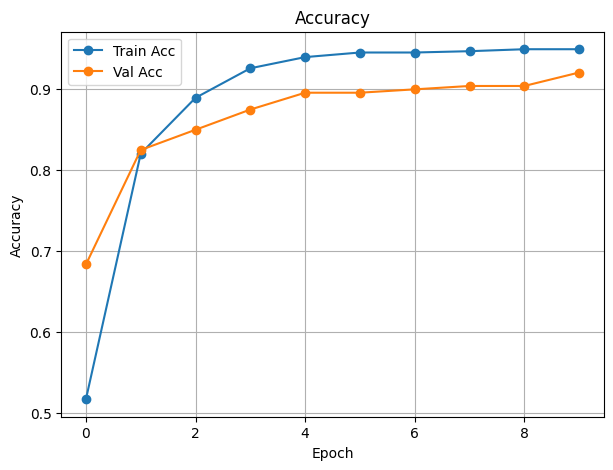

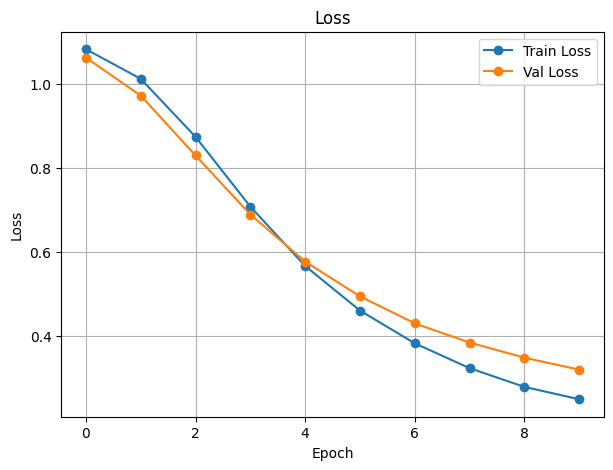

In [15]:
# Curves
plt.figure(figsize=(7,5))
plt.plot(train_accuracies, label="Train Acc", marker="o")
plt.plot(val_accuracies, label="Val Acc", marker="o")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="o")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss")
plt.legend(); plt.grid(True); plt.show()


In [16]:
@torch.no_grad()
def evaluate_with_metrics(loader, split_name="Val"):
    clip_model.eval(); fusion.eval(); classifier.eval()
    all_labels, all_preds = [], []

    for batch in loader:
        labels = batch["labels"].to(DEVICE)
        v, t = extract_features(batch)
        fused, _ = fusion(v, t)
        logits = classifier(fused)
        preds = logits.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"{split_name} Confusion Matrix")
    plt.show()

    print(f"\n{split_name} Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


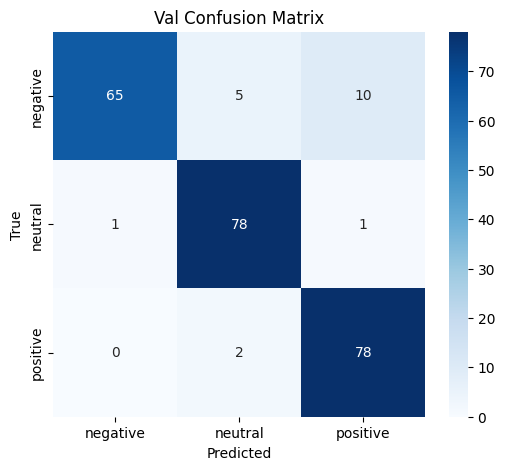


Val Classification Report:

              precision    recall  f1-score   support

    negative       0.98      0.81      0.89        80
     neutral       0.92      0.97      0.95        80
    positive       0.88      0.97      0.92        80

    accuracy                           0.92       240
   macro avg       0.93      0.92      0.92       240
weighted avg       0.93      0.92      0.92       240



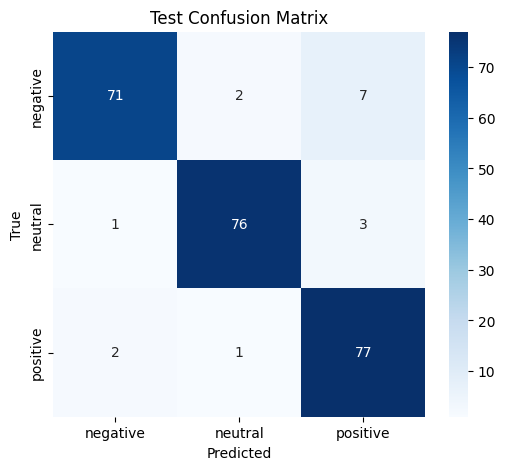


Test Classification Report:

              precision    recall  f1-score   support

    negative       0.96      0.89      0.92        80
     neutral       0.96      0.95      0.96        80
    positive       0.89      0.96      0.92        80

    accuracy                           0.93       240
   macro avg       0.94      0.93      0.93       240
weighted avg       0.94      0.93      0.93       240



In [17]:
evaluate_with_metrics(val_loader, split_name="Val")
# When ready for final testing:
evaluate_with_metrics(test_loader, split_name="Test")


In [1]:
@torch.no_grad()
def show_predictions(loader, num_images=6):
    clip_model.eval(); fusion.eval(); classifier.eval()
    import math
    samples = random.sample(loader.dataset.samples, k=min(num_images, len(loader.dataset)))
    cols = 3
    rows = math.ceil(len(samples)/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for ax, (img_path, true_label) in zip(axes, samples):
        img = Image.open(img_path).convert("RGB")

        # OCR text
        ocr_text = "dummy"
        if USE_OCR:
            try:
                reader = get_ocr_reader()
                ocr_texts = reader.readtext(np.array(img), detail=0)
                ocr_text = " ".join(ocr_texts).strip() or "no text"
            except Exception:
                ocr_text = "no text"

        # CLIP preprocess
        inputs = processor(images=img, text=[ocr_text], return_tensors="pt",
                           padding="max_length", truncation=True, max_length=77)
        pixel_values = inputs["pixel_values"].to(DEVICE)
        input_ids    = inputs["input_ids"].to(DEVICE)
        attn_mask    = inputs["attention_mask"].to(DEVICE)

        v = clip_model.get_image_features(pixel_values)
        t = clip_model.get_text_features(input_ids=input_ids, attention_mask=attn_mask)
        v = v / (v.norm(dim=-1, keepdim=True) + 1e-6)
        t = t / (t.norm(dim=-1, keepdim=True) + 1e-6)

        fused, alpha = fusion(v, t)
        logits = classifier(fused)
        pred_idx = logits.argmax(1).item()

        ax.imshow(img)
        title = f"T: {CLASS_NAMES[true_label]} | P: {CLASS_NAMES[pred_idx]}\n" \
                f"OCR: {ocr_text[:60]}{'...' if len(ocr_text)>60 else ''}\n" \
                f"α(vision)={alpha.item():.2f}"
        ax.set_title(title, color=("green" if pred_idx==true_label else "red"), fontsize=10)
        ax.axis("off")

    # Hide any extra axes
    for ax in axes[len(samples):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Run qualitative check
show_predictions(test_loader, num_images=6)


NameError: name 'torch' is not defined